In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

img_size = 224
batch_size = 32

train_dir = r"D:\python\deep learnig\brain tumer\dataset\Training"
val_dir   = r"D:\python\deep learnig\brain tumer\dataset\Testing"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [3]:
from tensorflow.keras.applications import DenseNet121

def build_model(base_model):
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [4]:
from tensorflow.keras.applications import DenseNet121

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

model = build_model(base_model)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [5]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 434s 2s/step - accuracy: 0.6493 - loss: 0.8848 - val_accuracy: 0.7594 - val_loss: 0.7169 - learning_rate: 1.0000e-04
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 439s 3s/step - accuracy: 0.7979 - loss: 0.5460 - val_accuracy: 0.8050 - val_loss: 0.6121 - learning_rate: 1.0000e-04
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 401s 2s/step - accuracy: 0.8321 - loss: 0.4466 - val_accuracy: 0.8156 - val_loss: 0.5771 - learning_rate: 1.0000e-04
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 406s 2s/step - accuracy: 0.8382 - loss: 0.4249 - val_accuracy: 0.8238 - val_loss: 0.5485 - learning_rate: 1.0000e-04
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 416s 2s/step - accuracy: 0.8557 - loss: 0.3859 - val_accuracy: 0.8269 - val_loss: 0.5325 - learning_rate: 1.0000e-04
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 425s 2s/step - accuracy: 0.8630 - loss: 0.3697 - val_accuracy: 0.8425 - val_loss: 0.5007 - learning_rate: 1.0000e-04
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 454s 3s/step - acc

In [6]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 748s 4s/step - accuracy: 0.9100 - loss: 0.2481 - val_accuracy: 0.8800 - val_loss: 0.4090
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 452s 3s/step - accuracy: 0.9096 - loss: 0.2398 - val_accuracy: 0.8844 - val_loss: 0.4227
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 438s 3s/step - accuracy: 0.9091 - loss: 0.2450 - val_accuracy: 0.8856 - val_loss: 0.4238
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.9125 - loss: 0.2325 - val_accuracy: 0.8838 - val_loss: 0.4313
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 396s 2s/step - accuracy: 0.9146 - loss: 0.2305 - val_accuracy: 0.8856 - val_loss: 0.4279
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 72836s 419s/step - accuracy: 0.9198 - loss: 0.2232 - val_accuracy: 0.8850 - val_loss: 0.4318
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 521s 3s/step - accuracy: 0.9150 - loss: 0.2293 - val_accuracy: 0.8838 - val_loss: 0.4311
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 625s 4s/step - accuracy: 0.9164 - loss: 0.2222 - val_

50/50 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step
              precision    recall  f1-score   support

           0       0.96      0.73      0.83       400
           1       0.83      0.83      0.83       400
           2       0.91      0.99      0.95       400
           3       0.86      0.99      0.92       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89      0.88      0.88      1600



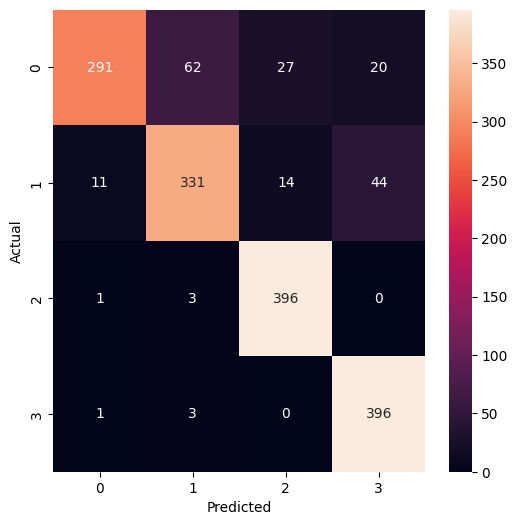

In [7]:
val_gen.reset()
pred = model.predict(val_gen)
y_pred = np.argmax(pred, axis=1)

print(classification_report(val_gen.classes, y_pred))

cm = confusion_matrix(val_gen.classes, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()